# Portfolio Project: SpaceX Falcon 9 First-Stage Landing Prediction
## 05 — Exploratory Data Analysis and Feature Engineering

**Portfolio Project | Business Analytics & Data Analytics**

This notebook continues the analytical workflow from Notebook 03 by exploring how **launch sequence, payload mass, launch site, orbit, and time** relate to Falcon 9 **first-stage landing success**. The second half of the notebook converts the cleaned analytical variables into a machine-learning-ready feature matrix.

### Research role of this stage
The purpose of exploratory data analysis (EDA) is not to prove causal relationships, but to identify patterns, heterogeneity, potential nonlinearities, and variables that may contain predictive information. The visual findings here guide the interpretation of the later dashboard and classification analyses.

### Workflow
1. Load the modeling-ready dataset produced in Notebook 03.
2. Validate schema, target balance, and date coverage.
3. Examine payload mass versus launch sequence.
4. Compare launch outcomes across launch sites.
5. Compare payload distributions across launch sites.
6. Estimate landing success rates by orbit.
7. Examine flight sequence and payload patterns within orbit categories.
8. Analyze yearly landing-success trends.
9. Add compact portfolio extensions for site-level and payload-band success rates.
10. Construct a one-hot-encoded feature matrix for predictive modeling.
11. Export the feature matrix for Notebook 08.

> **Continuity note.** The input file is `dataset_part_2_portfolio.csv`, the finalized output of Notebook 03. This keeps the portfolio pipeline local and reproducible.

## 1. Environment and data loading

The portfolio loads the local output `dataset_part_2_portfolio.csv` from Notebook 03 so that the analysis is self-contained and directly traceable to the wrangling stage.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

INPUT_PATH = Path("dataset_part_2_portfolio.csv")
FEATURE_OUTPUT_PATH = Path("dataset_part3_portfolio_audited.csv")

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"{INPUT_PATH} was not found. Run Notebook 03 first or place the file beside this notebook."
    )

df = pd.read_csv(INPUT_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="raise")

print(f"Loaded {len(df):,} rows × {df.shape[1]} columns from {INPUT_PATH}")
df.head()

Loaded 90 rows × 18 columns from dataset_part_2_portfolio.csv


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## 2. Data validation

Before plotting, the notebook verifies the sample size, target completeness, date range, and class distribution. This makes the EDA explicitly dependent on the same 90-launch historical sample established earlier in the portfolio.

In [2]:
validation = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "first_launch_date": df["Date"].min().date(),
    "last_launch_date": df["Date"].max().date(),
    "missing_target_values": int(df["Class"].isna().sum()),
    "successful_landings": int(df["Class"].sum()),
    "unsuccessful_or_no_success": int((df["Class"] == 0).sum()),
    "overall_success_rate": round(df["Class"].mean(), 4),
}, name="value")

validation.to_frame()

,value
rows,90
columns,18
first_launch_date,2010-06-04
last_launch_date,2020-11-05
missing_target_values,0
successful_landings,60
unsuccessful_or_no_success,30
overall_success_rate,0.6667


The historical sample contains **90 Falcon 9 missions**, including **60 successful landings and 30 unsuccessful/no-success outcomes**, for an overall observed landing-success rate of **66.67%**.

## 3. Flight number, payload mass, and landing outcome

The original EDA begins by plotting payload mass against flight number. This combines two potentially informative dimensions:

- **FlightNumber** acts as a rough proxy for program maturity and accumulated operational experience.
- **PayloadMass** captures mission scale and may influence recovery difficulty.

Because `Class` is binary, successful and unsuccessful landings are shown with different markers rather than relying on a categorical plotting wrapper.

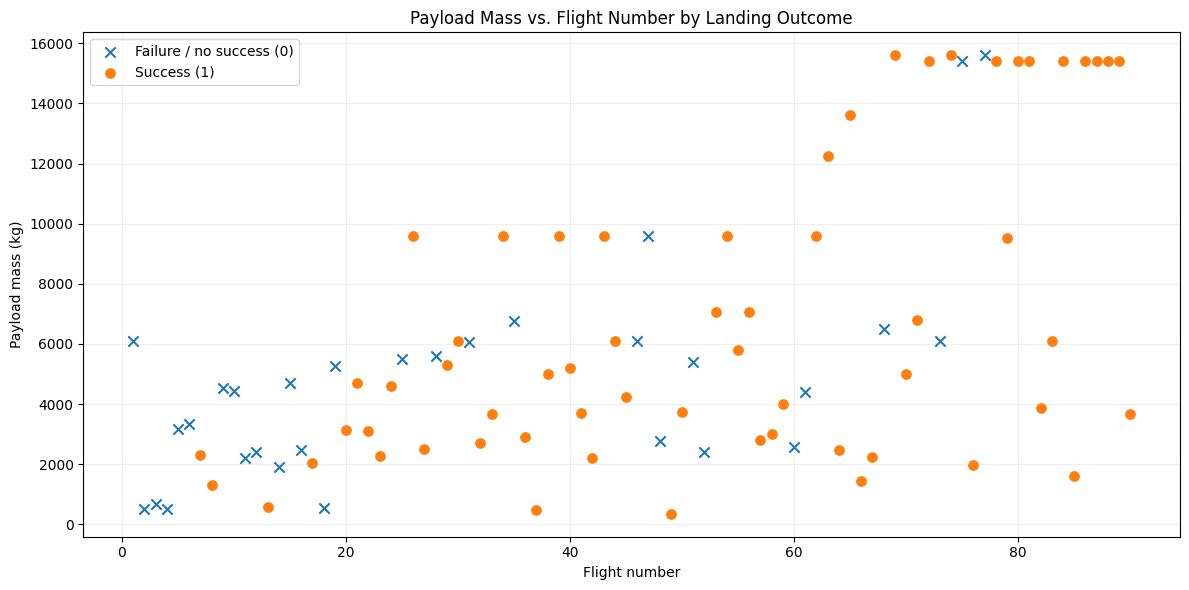

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

failure = df[df["Class"] == 0]
success = df[df["Class"] == 1]

ax.scatter(
    failure["FlightNumber"], failure["PayloadMass"],
    marker="x", s=55, label="Failure / no success (0)"
)
ax.scatter(
    success["FlightNumber"], success["PayloadMass"],
    marker="o", s=45, label="Success (1)"
)

ax.set_xlabel("Flight number")
ax.set_ylabel("Payload mass (kg)")
ax.set_title("Payload Mass vs. Flight Number by Landing Outcome")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows that successful landings are concentrated more heavily among later flight numbers, while successful and unsuccessful outcomes overlap substantially across the payload-mass range. In this sample, payload mass by itself therefore does not visually separate the two classes. Because flight number also advances with calendar time, the pattern is consistent with—rather than proof of—improving recovery performance as the program matured.

## 4. Flight number and launch site

The next view examines how launch outcomes evolved across the three launch sites over the historical sequence.

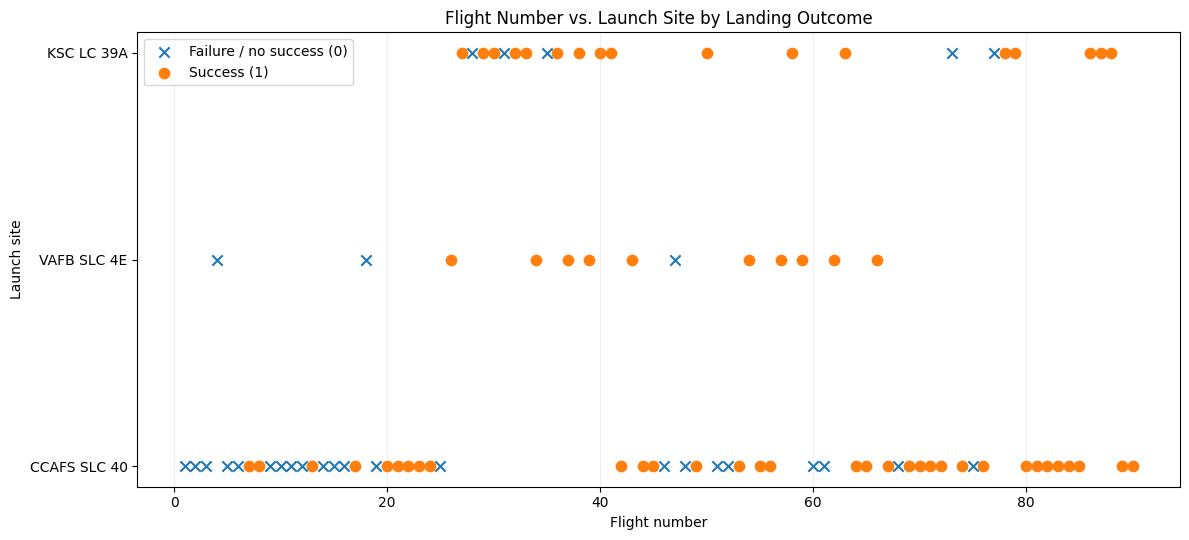

In [4]:
site_order = list(df["LaunchSite"].drop_duplicates())
site_to_y = {site: i for i, site in enumerate(site_order)}

fig, ax = plt.subplots(figsize=(12, 5.5))

for cls, marker, label in [
    (0, "x", "Failure / no success (0)"),
    (1, "o", "Success (1)")
]:
    subset = df[df["Class"] == cls]
    ax.scatter(
        subset["FlightNumber"],
        subset["LaunchSite"].map(site_to_y),
        marker=marker,
        s=55,
        label=label
    )

ax.set_yticks(range(len(site_order)))
ax.set_yticklabels(site_order)
ax.set_xlabel("Flight number")
ax.set_ylabel("Launch site")
ax.set_title("Flight Number vs. Launch Site by Landing Outcome")
ax.legend()
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

KSC had launched after around flight number 25;
VAFB had no launches after flight number 70;
While CCAFS performed emission in both early stage and later stage;

Across all three launch sites, successful landings are more prevalent among later flight numbers than among the earliest missions. The plot also shows that the sites were not used uniformly across the launch sequence. Consequently, differences observed between sites may be associated with mission timing and program maturity as well as with site-specific mission characteristics.

## 5. Payload mass and launch site

Payload distributions differ by site, which can confound simple comparisons of site-level success rates. Plotting payload against launch site helps separate mission composition from the recovery outcome itself.

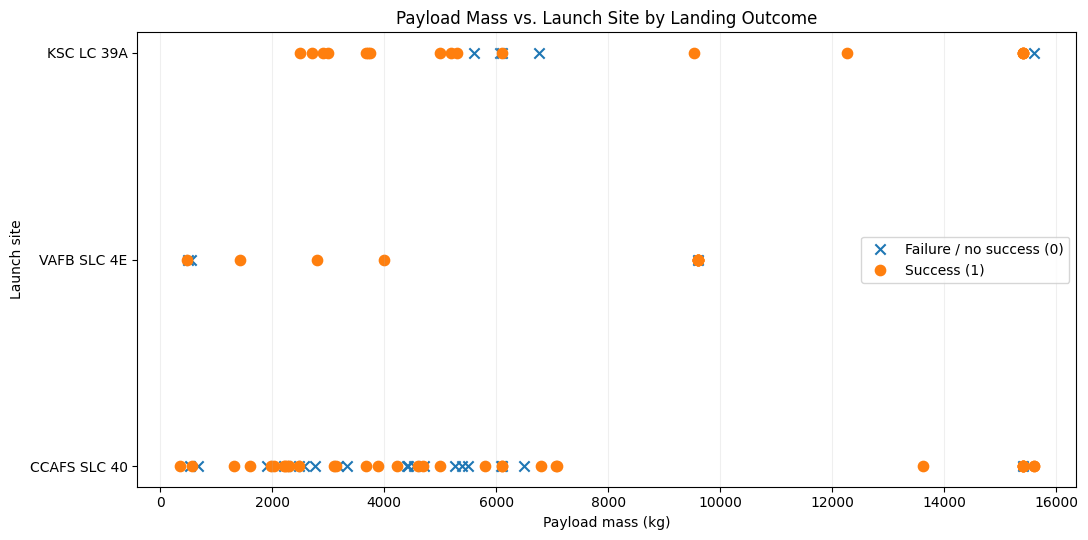

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for cls, marker, label in [
    (0, "x", "Failure / no success (0)"),
    (1, "o", "Success (1)")
]:
    subset = df[df["Class"] == cls]
    ax.scatter(
        subset["PayloadMass"],
        subset["LaunchSite"].map(site_to_y),
        marker=marker,
        s=55,
        label=label
    )

ax.set_yticks(range(len(site_order)))
ax.set_yticklabels(site_order)
ax.set_xlabel("Payload mass (kg)")
ax.set_ylabel("Launch site")
ax.set_title("Payload Mass vs. Launch Site by Landing Outcome")
ax.legend()
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

The three launch sites have visibly different payload distributions, and successful and unsuccessful outcomes overlap within those distributions. VAFB SLC 4E is represented across a more limited set of missions than CCAFS SLC 40, while the two Florida sites contain many of the higher-payload observations. These descriptive differences indicate that site comparisons should be interpreted together with mission composition rather than as isolated site effects.

## 6. Landing success rate by orbit

For a binary target, the group mean of `Class` is the empirical success rate. The notebook therefore estimates the observed landing success rate for each orbit category and reports the number of missions supporting each rate.

In [6]:
orbit_summary = (
    df.groupby("Orbit")
      .agg(
          Launches=("Class", "size"),
          Successes=("Class", "sum"),
          Success_Rate=("Class", "mean")
      )
      .sort_values(["Success_Rate", "Launches"], ascending=[False, False])
)

orbit_summary["Success_Rate_Pct"] = (100 * orbit_summary["Success_Rate"]).round(1)
orbit_summary

,Launches,Successes,Success_Rate,Success_Rate_Pct
Orbit,,,,
SSO,5,5,1.000000,100.0
ES-L1,1,1,1.000000,100.0
GEO,1,1,1.000000,100.0
HEO,1,1,1.000000,100.0
VLEO,14,12,0.857143,85.7
LEO,7,5,0.714286,71.4
PO,9,6,0.666667,66.7
MEO,3,2,0.666667,66.7
ISS,21,13,0.619048,61.9


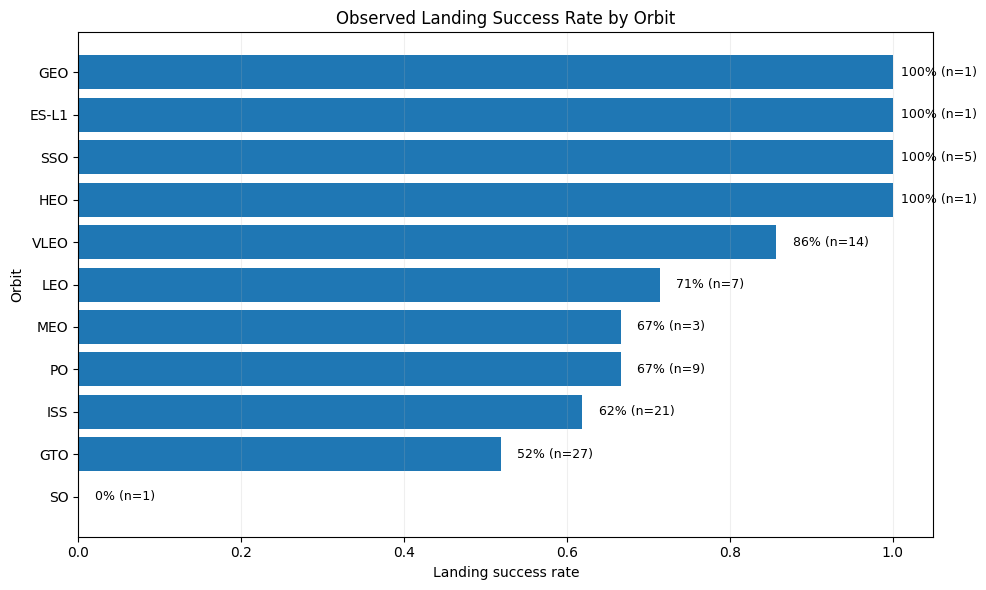

In [7]:
plot_data = orbit_summary.sort_values("Success_Rate")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data.index, plot_data["Success_Rate"])
ax.set_xlabel("Landing success rate")
ax.set_ylabel("Orbit")
ax.set_title("Observed Landing Success Rate by Orbit")
ax.set_xlim(0, 1.05)
ax.grid(axis="x", alpha=0.2)

for i, (rate, n) in enumerate(zip(plot_data["Success_Rate"], plot_data["Launches"])):
    ax.text(min(rate + 0.02, 1.01), i, f"{rate:.0%} (n={n})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

Several orbit categories show a 100% observed success rate, including ES-L1, GEO, HEO, and SSO. These rates should **not** be interpreted as evidence that those orbit types guarantee recovery success: several categories contain very few observations.

Among more frequently represented orbits, success rates are more informative. GTO missions show a lower observed success rate than LEO/VLEO in this historical sample, suggesting that mission profile may influence recovery conditions.

## 7. Flight number and orbit

Plotting flight sequence against orbit helps distinguish orbit effects from the strong temporal maturation pattern already observed.

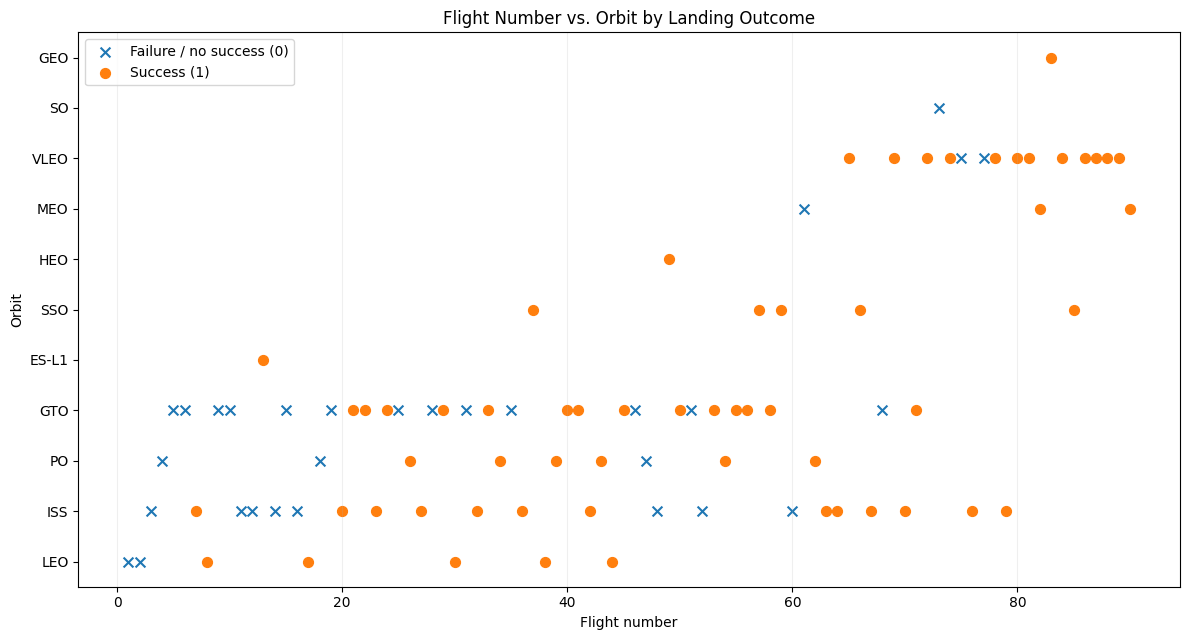

In [8]:
orbit_order = list(df["Orbit"].drop_duplicates())
orbit_to_y = {orbit: i for i, orbit in enumerate(orbit_order)}

fig, ax = plt.subplots(figsize=(12, 6.5))

for cls, marker, label in [
    (0, "x", "Failure / no success (0)"),
    (1, "o", "Success (1)")
]:
    subset = df[df["Class"] == cls]
    ax.scatter(
        subset["FlightNumber"],
        subset["Orbit"].map(orbit_to_y),
        marker=marker,
        s=50,
        label=label
    )

ax.set_yticks(range(len(orbit_order)))
ax.set_yticklabels(orbit_order)
ax.set_xlabel("Flight number")
ax.set_ylabel("Orbit")
ax.set_title("Flight Number vs. Orbit by Landing Outcome")
ax.legend()
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

GEO,SO,VLEO, and MEO launched at a fairly late stage with flight number larger than 60;\
HEO had only one launch at around No.50; and ES had only one lauch at around No.15;\
SSO launched both in the middle and upper range; while LEO lauched both in the early and middle range;\
GTO, PO, and ISS covered the entire range;

The plot also shows that orbit categories occur at different points in the launch sequence and that later observations contain a larger share of successful landings. Because orbit and flight sequence are not distributed independently in this historical sample, an apparent orbit-specific success pattern may also reflect changes in mission mix and recovery capability over time. Multivariate modeling is therefore more appropriate than interpreting this chart as an isolated orbit effect.

## 8. Payload mass and orbit

Payload distributions vary substantially across orbit categories. This chart helps reveal combinations of mission profile and payload mass associated with both successful and unsuccessful landings.

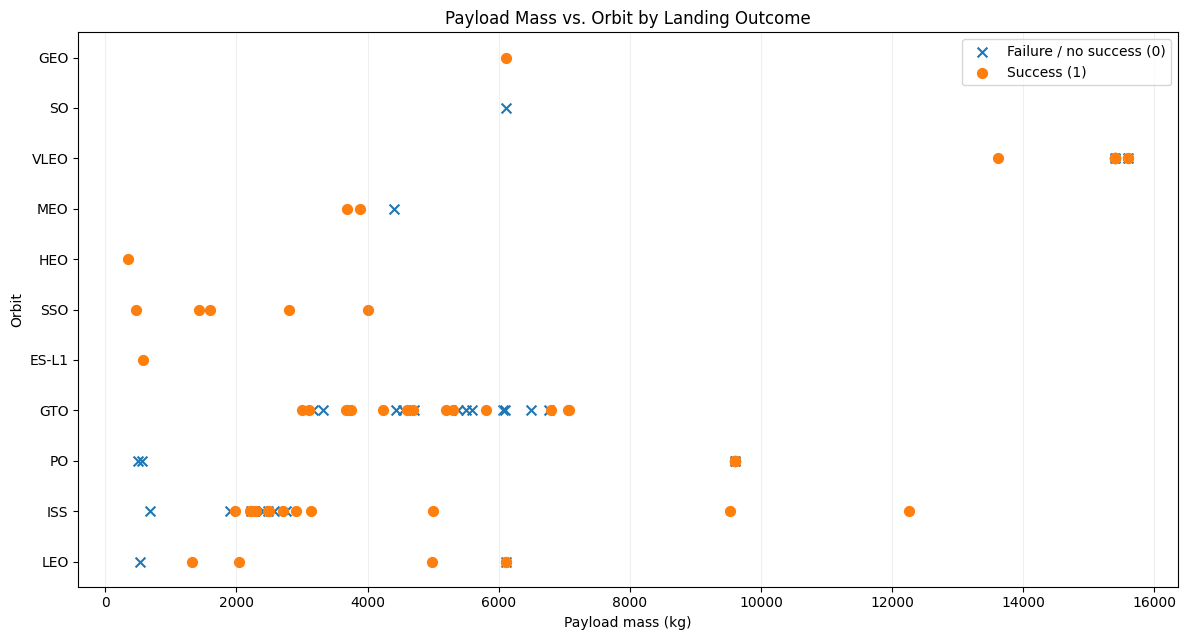

In [9]:
fig, ax = plt.subplots(figsize=(12, 6.5))

for cls, marker, label in [
    (0, "x", "Failure / no success (0)"),
    (1, "o", "Success (1)")
]:
    subset = df[df["Class"] == cls]
    ax.scatter(
        subset["PayloadMass"],
        subset["Orbit"].map(orbit_to_y),
        marker=marker,
        s=50,
        label=label
    )

ax.set_yticks(range(len(orbit_order)))
ax.set_yticklabels(orbit_order)
ax.set_xlabel("Payload mass (kg)")
ax.set_ylabel("Orbit")
ax.set_title("Payload Mass vs. Orbit by Landing Outcome")
ax.legend()
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

Heavier payloads appear across several successful mission categories, but the relationship differs by orbit. This supports treating payload and orbit jointly rather than interpreting payload mass as an isolated predictor.

## 9. Yearly landing-success trend

To analyze the yearly trend, we creates a separate `Year` variable from `Date`, which avoids losing information and makes the transformation more transparent.

In [10]:
df["Year"] = df["Date"].dt.year

yearly_summary = (
    df.groupby("Year")
      .agg(
          Launches=("Class", "size"),
          Successful_Landings=("Class", "sum"),
          Success_Rate=("Class", "mean")
      )
)

yearly_summary["Success_Rate_Pct"] = (100 * yearly_summary["Success_Rate"]).round(1)
yearly_summary

,Launches,Successful_Landings,Success_Rate,Success_Rate_Pct
Year,,,,
2010,1,0,0.000000,0.0
2012,1,0,0.000000,0.0
2013,3,0,0.000000,0.0
2014,6,2,0.333333,33.3
2015,6,2,0.333333,33.3
2016,8,5,0.625000,62.5
2017,18,15,0.833333,83.3
2018,18,11,0.611111,61.1
2019,10,9,0.900000,90.0


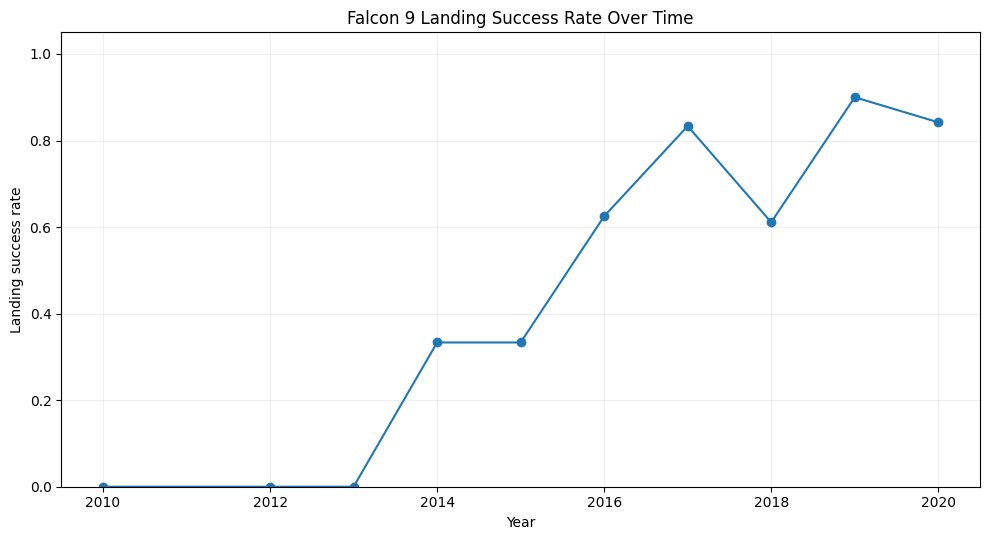

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    yearly_summary.index,
    yearly_summary["Success_Rate"],
    marker="o"
)

ax.set_xlabel("Year")
ax.set_ylabel("Landing success rate")
ax.set_title("Falcon 9 Landing Success Rate Over Time")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretation

The yearly results show a clear long-run improvement in observed landing success, but the increase is **not monotonic**. The rate rises from 0% in 2010–2013 to 33.3% in 2014–2015, 62.5% in 2016, and 83.3% in 2017; it then falls to 61.1% in 2018 before increasing to 90.0% in 2019 and 84.2% in 2020.

The broad **temporal** shift remains analytically important. A random train/test split can mix early experimental missions with later mature operations. **Notebook 08** will therefore supplement conventional random validation with a **time-aware holdout analysis** to examine generalization to later missions.

## 10. Success Rate by Launch Site

We then summarize site-level landing success rates, this compact aggregation provides that comparison while also reporting sample size.

In [12]:
site_summary = (
    df.groupby("LaunchSite")
      .agg(
          Launches=("Class", "size"),
          Successful_Landings=("Class", "sum"),
          Success_Rate=("Class", "mean")
      )
      .sort_values("Success_Rate", ascending=False)
)

site_summary["Success_Rate_Pct"] = (100 * site_summary["Success_Rate"]).round(1)
site_summary

,Launches,Successful_Landings,Success_Rate,Success_Rate_Pct
LaunchSite,,,,
KSC LC 39A,22,17,0.772727,77.3
VAFB SLC 4E,13,10,0.769231,76.9
CCAFS SLC 40,55,33,0.600000,60.0


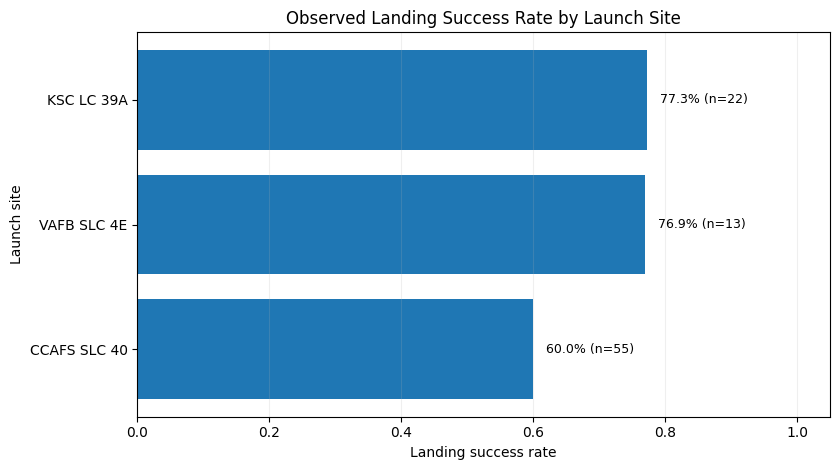

In [13]:
plot_data = site_summary.sort_values("Success_Rate")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(plot_data.index, plot_data["Success_Rate"])
ax.set_xlabel("Landing success rate")
ax.set_ylabel("Launch site")
ax.set_title("Observed Landing Success Rate by Launch Site")
ax.set_xlim(0, 1.05)
ax.grid(axis="x", alpha=0.2)

for i, (rate, n) in enumerate(zip(plot_data["Success_Rate"], plot_data["Launches"])):
    ax.text(min(rate + 0.02, 1.01), i, f"{rate:.1%} (n={n})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

KSC LC 39A has the highest observed landing-success rate in this historical sample, followed by VAFB SLC 4E and CCAFS SLC 40. However, this is a descriptive comparison only: launch site is associated with mission timing, orbit, payload, and booster characteristics, so the observed differences should not be interpreted causally.

## 11. Success Rate by Payload Band

To complement the continuous payload scatter plots, payload mass is grouped into broad bands. The bins are descriptive summaries rather than model features and are used only to visualize whether success rates vary across payload ranges.

In [14]:
payload_bins = [0, 2000, 4000, 6000, 8000, np.inf]
payload_labels = [
    "0–2,000",
    "2,000–4,000",
    "4,000–6,000",
    "6,000–8,000",
    "8,000+"
]

df["PayloadBand"] = pd.cut(
    df["PayloadMass"],
    bins=payload_bins,
    labels=payload_labels,
    include_lowest=True,
    right=False
)

payload_band_summary = (
    df.groupby("PayloadBand", observed=False)
      .agg(
          Launches=("Class", "size"),
          Successful_Landings=("Class", "sum"),
          Success_Rate=("Class", "mean")
      )
)

payload_band_summary["Success_Rate_Pct"] = (
    100 * payload_band_summary["Success_Rate"]
).round(1)

payload_band_summary

,Launches,Successful_Landings,Success_Rate,Success_Rate_Pct
PayloadBand,,,,
"0–2,000",12,7,0.583333,58.3
"2,000–4,000",26,18,0.692308,69.2
"4,000–6,000",17,9,0.529412,52.9
"6,000–8,000",12,6,0.500000,50.0
"8,000+",23,20,0.869565,87.0


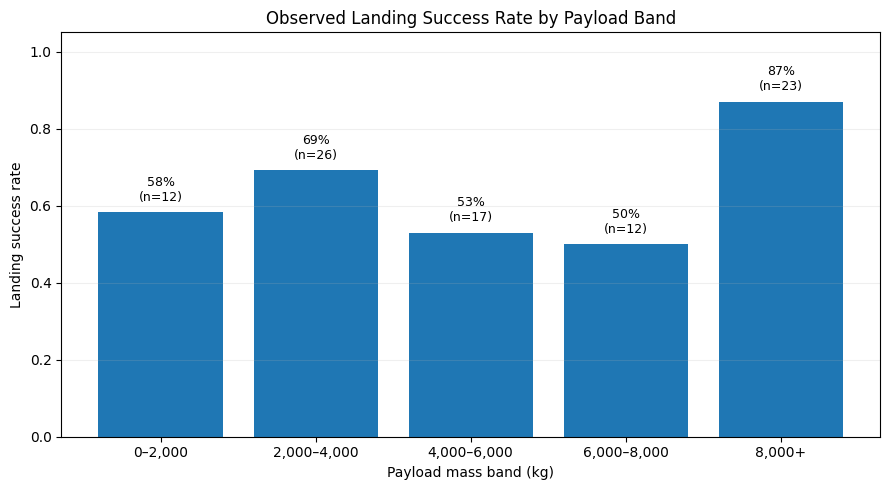

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    payload_band_summary.index.astype(str),
    payload_band_summary["Success_Rate"]
)

ax.set_xlabel("Payload mass band (kg)")
ax.set_ylabel("Landing success rate")
ax.set_title("Observed Landing Success Rate by Payload Band")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.2)

for i, (rate, n) in enumerate(
    zip(payload_band_summary["Success_Rate"], payload_band_summary["Launches"])
):
    if pd.notna(rate):
        ax.text(i, min(rate + 0.03, 1.01), f"{rate:.0%}\n(n={n})",
                ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

Landing success is **not monotonic** across the payload bands. The observed success rates are **58.3%** for 0–2,000 kg, **69.2%** for 2,000–4,000 kg, **52.9%** for 4,000–6,000 kg, **50.0%** for 6,000–8,000 kg, and **87.0%** for 8,000+ kg. The **8,000+ kg group has the highest observed success rate** in this sample (20 successes in 23 launches).

This does not imply that heavier payloads cause higher landing success. Payload mass is associated with other mission characteristics—including launch period, orbit, booster generation, and operational maturity—so the pattern should be treated as descriptive evidence and evaluated in a multivariate framework.

## 12. Feature engineering for predictive modeling

The modeling stage uses the feature set as below:

- numeric/ordinal variables: `FlightNumber`, `PayloadMass`, `Flights`, `Block`, `ReusedCount`;
- binary operational indicators: `GridFins`, `Reused`, `Legs`;
- categorical variables: `Orbit`, `LaunchSite`, `LandingPad`, and `Serial`.

The target variable `Class` is deliberately excluded from the feature matrix.

In [16]:
feature_columns = [
    "FlightNumber",
    "PayloadMass",
    "Orbit",
    "LaunchSite",
    "Flights",
    "GridFins",
    "Reused",
    "Legs",
    "LandingPad",
    "Block",
    "ReusedCount",
    "Serial",
]

features = df[feature_columns].copy()
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### 12.1 One-hot encode categorical variables

One-hot encoding converts categorical fields into indicator variables without imposing an artificial numerical order. The source dataset contains missing values only in `LandingPad`; these represent missions with no recorded landing pad. The portfolio workflow therefore labels those observations explicitly as `No landing pad` before encoding.

In [17]:
categorical_columns = ["Orbit", "LaunchSite", "LandingPad", "Serial"]

features_encoded = features.copy()
features_encoded["LandingPad"] = features_encoded["LandingPad"].fillna("No landing pad")

features_one_hot = pd.get_dummies(
    features_encoded,
    columns=categorical_columns,
    dtype=float
)

# Convert remaining boolean / numeric columns to float for model compatibility.
features_one_hot = features_one_hot.astype("float64")

print(f"Feature matrix shape: {features_one_hot.shape}")
features_one_hot.head()

Feature matrix shape: (90, 81)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,LandingPad_No landing pad,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 12.2 Feature-matrix validation

The final matrix should contain only numeric values, no missing data, and the same number of rows as the analytical dataset.

In [18]:
feature_validation = pd.Series({
    "rows": features_one_hot.shape[0],
    "columns": features_one_hot.shape[1],
    "all_numeric": bool(all(np.issubdtype(dtype, np.number) for dtype in features_one_hot.dtypes)),
    "missing_values": int(features_one_hot.isna().sum().sum()),
    "duplicate_feature_rows": int(features_one_hot.duplicated().sum()),
}, name="value")

feature_validation.to_frame()

,value
rows,90
columns,81
all_numeric,True
missing_values,0
duplicate_feature_rows,0


## 13. Export the machine-learning feature matrix

The notebook writes to `dataset_part3_portfolio_audited.csv`, leaving the earlier feature artifact untouched. This file is the feature input for the upgraded classification analysis in Notebook 08.

In [19]:
features_one_hot.to_csv(FEATURE_OUTPUT_PATH, index=False)
print(
    f"Saved feature matrix with {features_one_hot.shape[0]:,} rows × "
    f"{features_one_hot.shape[1]} columns to: {FEATURE_OUTPUT_PATH.resolve()}"
)

Saved feature matrix with 90 rows × 81 columns to: /mnt/data/dataset_part3_portfolio_audited.csv


## 14. EDA summary

The audited exploratory analysis supports the following conclusions:

- **Landing success improves substantially over the historical period, but not monotonically year by year.** Success rises from 0% in the earliest years to generally much higher rates in 2017–2020, with a notable decline in 2018.
- **Higher payload mass seems to associate with higher landing success.** Higher-payload missions—particularly the 8,000+ kg group—show a high observed success rate (87.0%), but success does not increase consistently across all payload ranges, suggesting that payload effects should be interpreted jointly with other mission characteristics.
- **Observed site success rates differ:** KSC LC 39A = **77.3%**, VAFB SLC 4E = **76.9%**, and CCAFS SLC 40 = **60.0%**. These are descriptive associations, not causal site effects.
- **Observed orbit success rates also differ substantially**, but several 100% categories contain only one or five missions and therefore should not be generalized without caution.
- **Mission characteristics are interrelated.** Orbit, payload, launch site, and launch sequence are distributed differently across the historical sample, supporting multivariate rather than one-variable interpretation.

### Methodological caution

These results describe a small observational historical dataset. They identify associations and candidate predictors but do not establish causal effects. Subgroup size, changing mission composition, booster evolution, and operational learning over time can all contribute to the observed patterns.

### Analytical handoff

The one-hot-encoded feature matrix produced here is used in Notebook 08. The final modeling stage will compare classifiers using multiple evaluation metrics and will explicitly examine temporal generalization rather than relying only on a random train/test split.

## Project attribution

This portfolio notebook builds on the visualization and feature-engineering stage of the **IBM Data Science Professional Certificate SpaceX capstone**. The original analytical flow and core variables are retained, while the implementation has been refactored for local reproducibility, clearer visualization, stronger validation, more cautious interpretation, and a cleaner transition into predictive modeling.